## Predicting Social Media Addiction and Its Impact on Academic Performance

In [1]:
# Necessary Python libraries

# for linear algebra and numerical operations
import numpy as np

# for data manipulation and analysis
import pandas as pd

# for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# for machine learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix

# machine learning models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

# Load Dataset

In [37]:
df = pd.read_csv('Effect of Social Media On Academic Performance of Students.csv')

df.head()

,Age,Grade Level,Hours on Social Media,Platforms,Device,Reasons,GPA,Affects Performance,Effect Details,Academic Use Frequency,Academic Use Type,Check Frequency,Overall Effect,Would Perform Better,Reduced Usage,Improvement Noted,Life Impact,Likes,Dislikes,Comments
0,16-18,College/University,More than 6 hours,"Instagram, Snapchat, WhatsApp",Smartphone,Educational purposes,3.5-4.0,Yes,Distracts me from studying,Frequently,Seeking help from peers/experts,Once or twice,Neutral,No,No,Not sure,Unsure,It connects the whole world,Improper content,Enough lead firm start show enjoy nation on.
1,16-18,College/University,3-4 hours,"Instagram, WhatsApp",Smartphone,News and updates,3.0-3.5,Yes,"Helps me with research and study groups, Distr...",Occasionally,"Seeking help from peers/experts, Joining study...",Once or twice,Mostly negative,Yes,Yes,No,Mostly negative,Wide range of resources,It causes procrastination,Enjoy everything reason while human then.
2,16-18,College/University,3-4 hours,"Instagram, WhatsApp",Smartphone,Socializing with friends,2.5-3.0,Yes,"Helps me with research and study groups, Cause...",Occasionally,Sharing academic resources,Once or twice,Mostly positive,Yes,Not sure,Not sure,Neutral,Wide range of resources,Information insecurity and rumors,Voice different nation ahead education member ...
3,16-18,College/University,More than 6 hours,Instagram,Smartphone,"News and updates, Professional networking, Ent...",3.0-3.5,No,"Motivates me through educational content, Caus...",Frequently,"Watching educational videos, Participating in ...",Every hour,Neutral,Not sure,Not sure,No,Unsure,Awareness,It causes procrastination,Positive truth brother vote year environment.
4,Over 21,College/University,1-2 hours,YouTube,Laptop,"Professional networking, Entertainment, News a...",2.5-3.0,Yes,"Causes me to procrastinate, Motivates me throu...",Frequently,"Watching educational videos, Joining study gro...",Every hour,Mostly negative,Yes,Not sure,Yes,Mostly positive,Socializing with friends,Addiction,Itself light hear player.


# Exploratory Data Analysis (EDA)

In [41]:
# display dataset information
df.info()

# check missing values
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Age                     300 non-null    object
 1   Grade Level             300 non-null    object
 2   Hours on Social Media   300 non-null    object
 3   Platforms               300 non-null    object
 4   Device                  300 non-null    object
 5   Reasons                 300 non-null    object
 6   GPA                     300 non-null    object
 7   Affects Performance     300 non-null    object
 8   Effect Details          300 non-null    object
 9   Academic Use Frequency  300 non-null    object
 10  Academic Use Type       300 non-null    object
 11  Check Frequency         300 non-null    object
 12  Overall Effect          300 non-null    object
 13  Would Perform Better    300 non-null    object
 14  Reduced Usage           300 non-null    object
 15  Improv

,0
Age,0
Grade Level,0
Hours on Social Media,0
Platforms,0
Device,0
Reasons,0
GPA,0
Affects Performance,0
Effect Details,0
Academic Use Frequency,0


In [4]:
# statistical summary
df.describe()

,Age,Grade Level,Hours on Social Media,Platforms,Device,Reasons,GPA,Affects Performance,Effect Details,Academic Use Frequency,Academic Use Type,Check Frequency,Overall Effect,Would Perform Better,Reduced Usage,Improvement Noted,Life Impact,Likes,Dislikes,Comments
count,300,300,300,300,300,300,300,300,300,300,300,300,300,300,300,300,300,300,300,300
unique,3,1,5,7,3,71,4,3,40,3,124,3,4,3,3,3,4,6,6,300
top,19-21,College/University,3-4 hours,Instagram,Smartphone,Professional networking,3.0-3.5,Yes,Motivates me through educational content,Always,Watching educational videos,Once or twice,Unsure,No,Yes,Not sure,Mostly negative,Entertainment,Nothing,Rule alone car candidate ten class.
freq,184,300,75,48,221,23,96,185,27,103,16,102,87,102,108,112,80,68,56,1


"""
The dataset contains 300 records and 20 features.
There are no missing values.
However, all data is categorical, so preprocessing is required.
"""


#Data Preprocessing

In [6]:
# remove extra spaces from column names
df.columns = df.columns.str.strip()

df.head()

,Age,Grade Level,Hours on Social Media,Platforms,Device,Reasons,GPA,Affects Performance,Effect Details,Academic Use Frequency,Academic Use Type,Check Frequency,Overall Effect,Would Perform Better,Reduced Usage,Improvement Noted,Life Impact,Likes,Dislikes,Comments
0,16-18,College/University,More than 6 hours,"Instagram, Snapchat, WhatsApp",Smartphone,Educational purposes,3.5-4.0,Yes,Distracts me from studying,Frequently,Seeking help from peers/experts,Once or twice,Neutral,No,No,Not sure,Unsure,It connects the whole world,Improper content,Enough lead firm start show enjoy nation on.
1,16-18,College/University,3-4 hours,"Instagram, WhatsApp",Smartphone,News and updates,3.0-3.5,Yes,"Helps me with research and study groups, Distr...",Occasionally,"Seeking help from peers/experts, Joining study...",Once or twice,Mostly negative,Yes,Yes,No,Mostly negative,Wide range of resources,It causes procrastination,Enjoy everything reason while human then.
2,16-18,College/University,3-4 hours,"Instagram, WhatsApp",Smartphone,Socializing with friends,2.5-3.0,Yes,"Helps me with research and study groups, Cause...",Occasionally,Sharing academic resources,Once or twice,Mostly positive,Yes,Not sure,Not sure,Neutral,Wide range of resources,Information insecurity and rumors,Voice different nation ahead education member ...
3,16-18,College/University,More than 6 hours,Instagram,Smartphone,"News and updates, Professional networking, Ent...",3.0-3.5,No,"Motivates me through educational content, Caus...",Frequently,"Watching educational videos, Participating in ...",Every hour,Neutral,Not sure,Not sure,No,Unsure,Awareness,It causes procrastination,Positive truth brother vote year environment.
4,Over 21,College/University,1-2 hours,YouTube,Laptop,"Professional networking, Entertainment, News a...",2.5-3.0,Yes,"Causes me to procrastinate, Motivates me throu...",Frequently,"Watching educational videos, Joining study gro...",Every hour,Mostly negative,Yes,Not sure,Yes,Mostly positive,Socializing with friends,Addiction,Itself light hear player.


In [7]:
# convert GPA range to numeric (take average)
def convert_gpa(gpa):
    if '-' in gpa:
        parts = gpa.split('-')
        return (float(parts[0]) + float(parts[1])) / 2
    else:
        return float(gpa)

df['GPA'] = df['GPA'].apply(convert_gpa)

In [12]:
# convert hours to numeric
def convert_hours(hours):
    hours = hours.strip()  # remove spaces

    if 'More than' in hours:
        return 6
    elif 'Less than' in hours:
        return 1
    elif '-' in hours:
        parts = hours.replace(' hours', '').split('-')
        return (int(parts[0]) + int(parts[1])) / 2
    else:
        return int(hours.replace(' hours', ''))

df['Hours on Social Media'] = df['Hours on Social Media'].apply(convert_hours)


# Feature Selection & Encoding

In [13]:
features = [
    'Age',
    'Grade Level',
    'Hours on Social Media',
    'GPA',
    'Affects Performance',
    'Academic Use Frequency',
    'Overall Effect'
]

In [42]:
df_model = df[features].copy()

le = LabelEncoder()

for col in df_model.columns:
    if df_model[col].dtype == 'object':
        df_model[col] = le.fit_transform(df_model[col])

# Train-Test Split

In [17]:
X = df_model.drop('Overall Effect', axis=1)
y = df_model['Overall Effect']

In [20]:
# split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [19]:
print(X_train.shape)
print(X_test.shape)

(240, 6)
(60, 6)


# 1 Logistic Regression Model

In [44]:
# create Logistic Regression model
model_lr = LogisticRegression()

# train the model
model_lr.fit(X_train, y_train)

# make predictions
y_pred_lr = model_lr.predict(X_test)

In [45]:
# calculate accuracy
acc_lr = accuracy_score(y_test, y_pred_lr)
print("Logistic Regression Accuracy:", acc_lr)
print(confusion_matrix(y_test, y_pred_lr))


Logistic Regression Accuracy: 0.23333333333333334
[[0 1 6 6]
 [4 1 9 4]
 [1 1 9 4]
 [1 2 7 4]]


## 2 K-Nearest Neighbors (KNN)

In [46]:
# create KNN model
model_knn = KNeighborsClassifier(n_neighbors=5)

# train
model_knn.fit(X_train, y_train)

# predict
y_pred_knn = model_knn.predict(X_test)

In [47]:
acc_knn = accuracy_score(y_test, y_pred_knn)
print("KNN Accuracy:", acc_knn)

print(confusion_matrix(y_test, y_pred_knn))

KNN Accuracy: 0.23333333333333334
[[1 3 7 2]
 [3 4 7 4]
 [1 5 5 4]
 [3 4 3 4]]


## 3 Decision Tree Model

In [48]:
# create Decision Tree model
model_dt = DecisionTreeClassifier()

# train
model_dt.fit(X_train, y_train)

# predict
y_pred_dt = model_dt.predict(X_test)

In [49]:
# accuracy
acc_dt = accuracy_score(y_test, y_pred_dt)
print("Decision Tree Accuracy:", acc_dt)

# confusion matrix
print(confusion_matrix(y_test, y_pred_dt))

Decision Tree Accuracy: 0.3
[[3 1 6 3]
 [4 3 3 8]
 [3 2 7 3]
 [4 1 4 5]]


# Model Comparison

In [27]:
# compare models
print("Logistic Regression:", acc_lr)
print("KNN:", acc_knn)
print("Decision Tree:", acc_dt)

Logistic Regression: 0.23333333333333334
KNN: 0.23333333333333334
Decision Tree: 0.26666666666666666


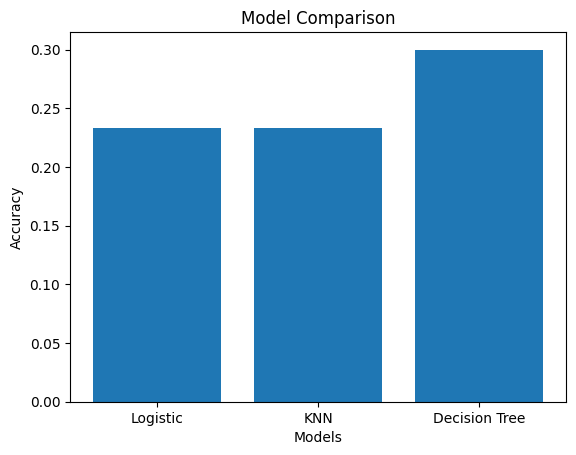

In [50]:
models = ['Logistic', 'KNN', 'Decision Tree']
scores = [acc_lr, acc_knn, acc_dt]

plt.bar(models, scores)
plt.title("Model Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.show()

# Data Analysis (Impact on GPA)


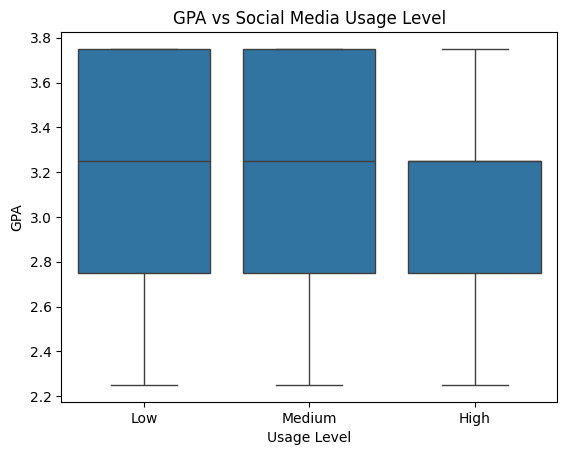

In [36]:
df['Usage Level'] = pd.cut(df['Hours on Social Media'],
                          bins=[0,2,4,6],
                          labels=['Low', 'Medium', 'High'])
sns.boxplot(x='Usage Level', y='GPA', data=df)
plt.title("GPA vs Social Media Usage Level")
plt.show()